In [1]:
print("Student Performance Prediction Project")

Student Performance Prediction Project


In [2]:
import pandas as pd

data = {
    "Study_Hours": [2, 3, 4, 5, 6, 7, 8, 9, 1, 4,
                    6, 7, 3, 5, 8, 2, 9, 6, 7, 4],

    "Attendance": [55, 60, 65, 70, 75, 80, 85, 90, 50, 68,
                   78, 82, 62, 72, 92, 58, 95, 76, 88, 66],

    "Previous_Marks": [45, 50, 55, 60, 65, 70, 75, 85, 40, 58,
                       68, 72, 52, 62, 88, 48, 90, 67, 80, 56],

    "Assignment_Score": [50, 55, 60, 65, 70, 75, 80, 90, 45, 62,
                         72, 78, 58, 68, 92, 52, 95, 73, 85, 60],

    "Final_Marks": [48, 52, 58, 63, 68, 73, 78, 88, 42, 61,
                    71, 77, 55, 65, 91, 50, 94, 70, 83, 59]
}

df = pd.DataFrame(data)

df.head()

,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Final_Marks
0,2,55,45,50,48
1,3,60,50,55,52
2,4,65,55,60,58
3,5,70,60,65,63
4,6,75,65,70,68


In [4]:
print("Number of students:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumn names:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Number of students: 20
Number of columns: 5

Column names:
Index(['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignment_Score',
       'Final_Marks'],
      dtype='object')

Missing values:
Study_Hours         0
Attendance          0
Previous_Marks      0
Assignment_Score    0
Final_Marks         0
dtype: int64


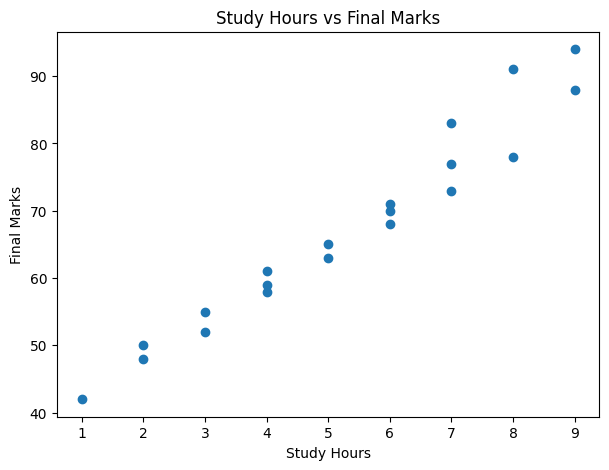

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(df["Study_Hours"], df["Final_Marks"])

plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")

plt.show()

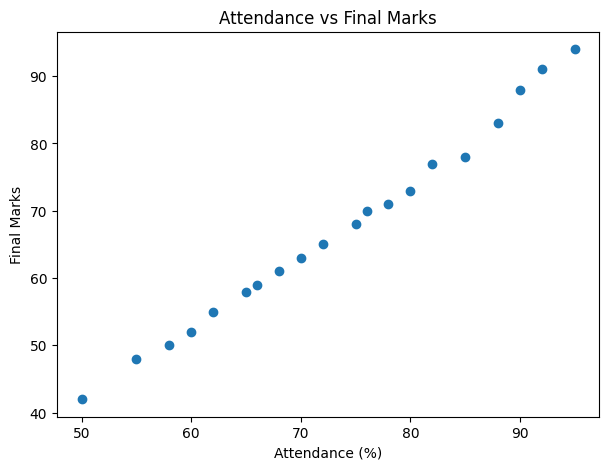

In [6]:
plt.figure(figsize=(7,5))

plt.scatter(df["Attendance"], df["Final_Marks"])

plt.xlabel("Attendance (%)")
plt.ylabel("Final Marks")
plt.title("Attendance vs Final Marks")

plt.show()

In [7]:
# Select input features
X = df[["Study_Hours", "Attendance", "Previous_Marks", "Assignment_Score"]]

# Select the target/output
y = df["Final_Marks"]

print("Input data:")
print(X.head())

print("\nTarget data:")
print(y.head())

Input data:
   Study_Hours  Attendance  Previous_Marks  Assignment_Score
0            2          55              45                50
1            3          60              50                55
2            4          65              55                60
3            5          70              60                65
4            6          75              65                70

Target data:
0    48
1    52
2    58
3    63
4    68
Name: Final_Marks, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 16
Testing data: 4


In [9]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [10]:
# Predict marks for the test students
y_pred = model.predict(X_test)

print("Predicted Marks:")
print(y_pred)

print("\nActual Marks:")
print(y_test.values)

Predicted Marks:
[47.44775168 70.44523315 50.31109872 52.62737767]

Actual Marks:
[48 70 50 52]


In [11]:
from sklearn.metrics import r2_score, mean_absolute_error

# Calculate R2 score
r2 = r2_score(y_test, y_pred)

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("Mean Absolute Error:", mae)

R2 Score: 0.9967740392248983
Mean Absolute Error: 0.48398946535762555


In [13]:
# Details of a new student
study_hours = 6
attendance = 85
previous_marks = 72
assignment_score = 80

# Make prediction
new_student = pd.DataFrame({
    "Study_Hours": [study_hours],
    "Attendance": [attendance],
    "Previous_Marks": [previous_marks],
    "Assignment_Score": [assignment_score]
})

predicted_marks = model.predict(new_student)

print("Predicted Final Marks:", round(predicted_marks[0], 2))
predicted_marks=model.predict(new_student)
print("predicted final marks:",round(predicted_marks[0],2))

Predicted Final Marks: 77.03
predicted final marks: 77.03


In [14]:
# Classify student performance

if predicted_marks[0] >= 80:
    category = "Excellent"
elif predicted_marks[0] >= 60:
    category = "Good"
elif predicted_marks[0] >= 40:
    category = "Average"
else:
    category = "Needs Improvement"

print("Predicted Final Marks:", round(predicted_marks[0], 2))
print("Performance Category:", category)

Predicted Final Marks: 77.03
Performance Category: Good


In [17]:
# Student Performance Prediction System

study_hours = float(input("Enter Study Hours: "))
attendance = float(input("Enter Attendance (%): "))
previous_marks = float(input("Enter Previous Marks: "))
assignment_score = float(input("Enter Assignment Score: "))

# Create input for the model
new_student = pd.DataFrame({
    "Study_Hours": [study_hours],
    "Attendance": [attendance],
    "Previous_Marks": [previous_marks],
    "Assignment_Score": [assignment_score]
})

# Predict final marks
predicted_marks = model.predict(new_student)

# Performance category
if predicted_marks[0] >= 80:
    category = "Excellent"
elif predicted_marks[0] >= 60:
    category = "Good"
elif predicted_marks[0] >= 40:
    category = "Average"
else:
    category = "Needs Improvement"

print("\n--- Student Performance Result ---")
print("Predicted Final Marks:", round(predicted_marks[0], 2))
print("Performance Category:", category)

Enter Study Hours: 7
Enter Attendance (%): 90
Enter Previous Marks: 75
Enter Assignment Score: 85

--- Student Performance Result ---
Predicted Final Marks: 81.05
Performance Category: Excellent


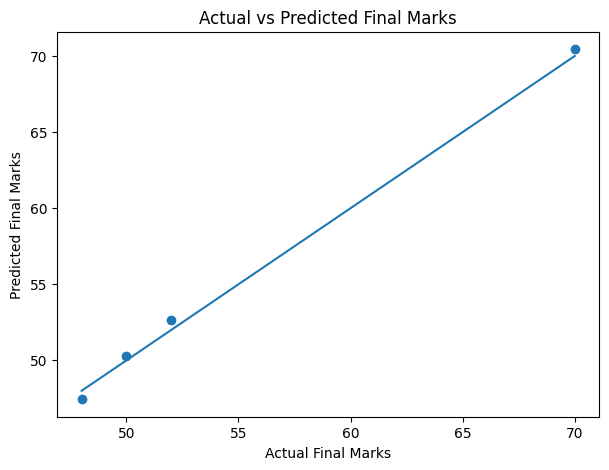

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")
plt.title("Actual vs Predicted Final Marks")

# Reference line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

In [18]:
# Simple Student Performance Prediction Interface

print("======================================")
print("   STUDENT PERFORMANCE PREDICTION")
print("======================================")

study_hours = float(input("Enter Study Hours: "))
attendance = float(input("Enter Attendance (%): "))
previous_marks = float(input("Enter Previous Marks: "))
assignment_score = float(input("Enter Assignment Score: "))

# Prepare student data
new_student = pd.DataFrame({
    "Study_Hours": [study_hours],
    "Attendance": [attendance],
    "Previous_Marks": [previous_marks],
    "Assignment_Score": [assignment_score]
})

# Predict final marks
prediction = model.predict(new_student)[0]

# Performance category
if prediction >= 80:
    performance = "Excellent"
elif prediction >= 60:
    performance = "Good"
elif prediction >= 40:
    performance = "Average"
else:
    performance = "Needs Improvement"

print("\n======================================")
print("             RESULT")
print("======================================")
print("Predicted Final Marks:", round(prediction, 2))
print("Performance Category:", performance)
print("======================================")

   STUDENT PERFORMANCE PREDICTION
Enter Study Hours: 8
Enter Attendance (%): 90
Enter Previous Marks: 85
Enter Assignment Score: 90

             RESULT
Predicted Final Marks: 88.33
Performance Category: Excellent


In [19]:
# Create a larger student dataset

import pandas as pd

data = {
    "Study_Hours": [1,2,2,3,3,4,4,5,5,6,6,7,7,8,8,9,9,4,6,7],
    "Attendance": [50,55,60,62,65,68,70,72,75,78,80,82,85,88,90,92,95,66,79,87],
    "Previous_Marks": [40,45,48,50,53,55,58,60,62,65,68,70,73,76,80,83,88,54,67,75],
    "Assignment_Score": [42,50,52,55,58,60,63,65,68,70,72,75,78,82,85,88,92,57,71,80],
    "Final_Marks": [42,48,50,53,56,59,62,65,67,70,73,76,79,83,87,90,94,58,72,81]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Number of students:", len(df))

df.head()

Dataset created successfully!
Number of students: 20


,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Final_Marks
0,1,50,40,42,42
1,2,55,45,50,48
2,2,60,48,52,50
3,3,62,50,55,53
4,3,65,53,58,56


In [21]:
# Generate a larger student dataset

import numpy as np
import pandas as pd

np.random.seed(42)

n = 500

study_hours = np.random.randint(1, 11, n)
attendance = np.random.randint(50, 101, n)
previous_marks = np.random.randint(40, 91, n)
assignment_score = np.random.randint(40, 101, n)

# Generate final marks based on student performance
final_marks = (
    0.25 * (study_hours * 10)
    + 0.25 * attendance
    + 0.25 * previous_marks
    + 0.25 * assignment_score
    + np.random.normal(0, 3, n)
)

final_marks = np.clip(final_marks, 0, 100).round(0).astype(int)

df = pd.DataFrame({
    "Study_Hours": study_hours,
    "Attendance": attendance,
    "Previous_Marks": previous_marks,
    "Assignment_Score": assignment_score,
    "Final_Marks": final_marks
})

print("Dataset created successfully!")
print("Number of students:", len(df))

df.head()

Dataset created successfully!
Number of students: 500


,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Final_Marks
0,7,90,88,57,76
1,4,79,44,70,56
2,8,66,83,69,71
3,5,98,89,91,81
4,7,69,53,78,73


In [22]:
X = df[["Study_Hours", "Attendance", "Previous_Marks", "Assignment_Score"]]
y = df["Final_Marks"]

print("Features and target selected successfully!")
print("Number of students:", len(df))

Features and target selected successfully!
Number of students: 500


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training students:", len(X_train))
print("Testing students:", len(X_test))

Training students: 400
Testing students: 100


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Select features and target
X = df[["Study_Hours", "Attendance", "Previous_Marks", "Assignment_Score"]]
y = df["Final_Marks"]

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Training students:", len(X_train))
print("Testing students:", len(X_test))

Model trained successfully!
Training students: 400
Testing students: 100


In [25]:
from sklearn.metrics import r2_score, mean_absolute_error

# Make predictions for the test students
y_pred = model.predict(X_test)

# Calculate accuracy measures
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Model Evaluation")
print("-------------------------")
print("R2 Score:", round(r2, 3))
print("Mean Absolute Error:", round(mae, 2))

Model Evaluation
-------------------------
R2 Score: 0.909
Mean Absolute Error: 2.7


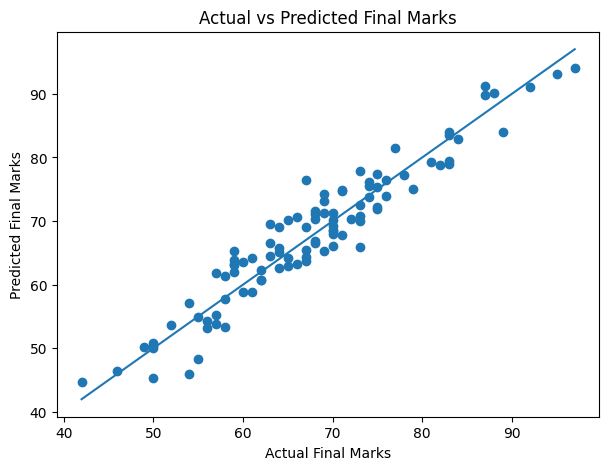

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")
plt.title("Actual vs Predicted Final Marks")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

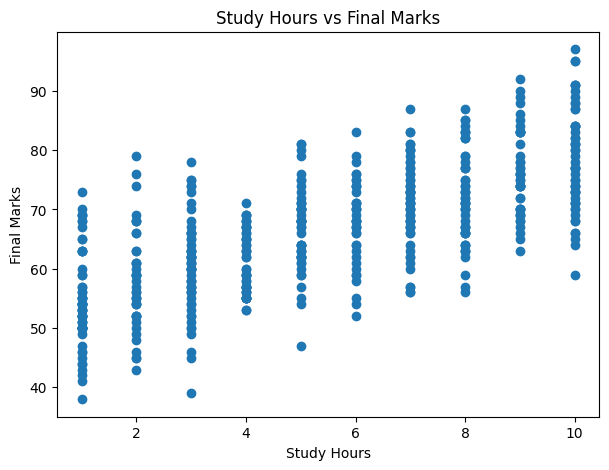

In [27]:
plt.figure(figsize=(7, 5))

plt.scatter(df["Study_Hours"], df["Final_Marks"])

plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")

plt.show()

In [28]:
print("======================================")
print("   STUDENT PERFORMANCE PREDICTION")
print("======================================")

study_hours = float(input("Enter Study Hours: "))
attendance = float(input("Enter Attendance (%): "))
previous_marks = float(input("Enter Previous Marks: "))
assignment_score = float(input("Enter Assignment Score: "))

new_student = pd.DataFrame({
    "Study_Hours": [study_hours],
    "Attendance": [attendance],
    "Previous_Marks": [previous_marks],
    "Assignment_Score": [assignment_score]
})

prediction = model.predict(new_student)[0]

# Keep marks between 0 and 100
prediction = max(0, min(100, prediction))

if prediction >= 80:
    performance = "Excellent"
elif prediction >= 60:
    performance = "Good"
elif prediction >= 40:
    performance = "Average"
else:
    performance = "Needs Improvement"

print("\n======================================")
print("             RESULT")
print("======================================")
print("Predicted Final Marks:", round(prediction, 2))
print("Performance Category:", performance)
print("======================================")

   STUDENT PERFORMANCE PREDICTION
Enter Study Hours: 7
Enter Attendance (%): 90
Enter Previous Marks: 75
Enter Assignment Score: 85

             RESULT
Predicted Final Marks: 80.38
Performance Category: Excellent


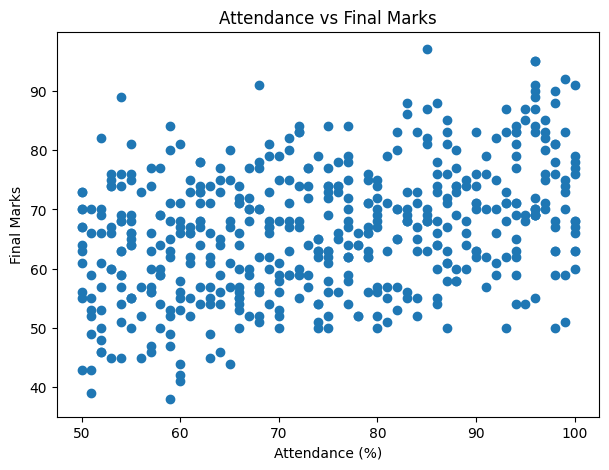

In [29]:
plt.figure(figsize=(7, 5))

plt.scatter(df["Attendance"], df["Final_Marks"])

plt.xlabel("Attendance (%)")
plt.ylabel("Final Marks")
plt.title("Attendance vs Final Marks")

plt.show()